# DZO Assignment: Image Editing in the Gradient Domain 

### 1. Read images and mask and try to combine them 


In [11]:
%load_ext autoreload
%autoreload 2

from poisson import *
from DZO.utils import imread

import numpy as np
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['figure.figsize'] = (4, 4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


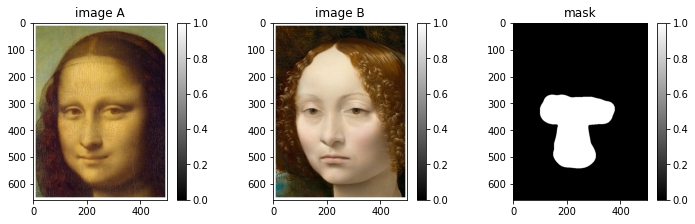

In [12]:
im_A = imread('mona_lisa.png').astype(float)/255
im_B = imread('ginevra_benci.png').astype(float)/255
mask = imread('mona_mask.png').astype(float)/255
# We want M to be 2D (= all channels are masked the same way)
mask = mask[:,:,0]

# let's have a look at the images, and the mask
show_tuple([im_A, im_B, mask], captions=['image A', 'image B', 'mask'])


Try to combine the images in intensity domain - just by pasting:

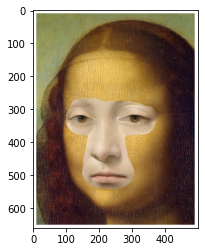

In [13]:
im_merged = merge_images(im_A, im_B, mask)
plt.imshow(im_merged)


### Combining images in the gradient domain 
We will combine images not in the intensity domain but in the gradient domain. First, compute the gradients - this time using simple, forward differences because it is most fitting to the task. 

Also, learn how to display the gradients.

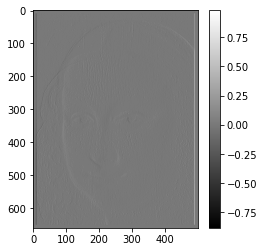

In [14]:
# calculate gradient of both images: 
[gx_A, gy_A] = calc_grad(im_A)
[gx_B, gy_B] = calc_grad(im_B)
# show e.g. gx of the first channel of A: 
plt.imshow(gx_A[:,:,0], cmap='gray'); plt.colorbar() 


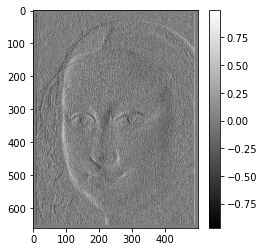

In [15]:
# The gradient is visible, but let us help to ease the visualization a bit. 
# How about if we transform the gradient magnitude, using the prepared function signed_sqrt?
# (make sure you know what the function is doing)
plt.imshow(signed_power( gx_A[:,:,0], beta=1/4), cmap='gray'); plt.colorbar() 

We know from the theory that after merging the gradients, we will need to compute the divergence of the new gradient field:

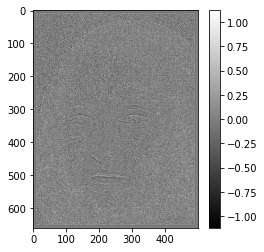

In [16]:
gx, gy = merge_grads(gx_A, gy_A, gx_B, gy_B, mask)
divergence = calc_div(gx, gy)
# show a given divergence channel (have a look at other channels, too)
plt.imshow(signed_power(divergence[:,:,2], 1/5), cmap='gray'); plt.colorbar()


Now solve for the intensities. First, use Gauss-Seidel iterations in order to compute the solutions. 

Text(0.5, 1.0, 'merged, GS solver')

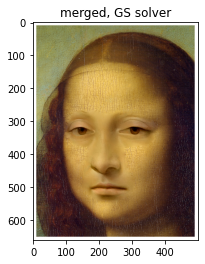

In [17]:
o = solve_GS(divergence, im_A, mask, num_iter = 300)
# note the np.clip here; computing intensities may bring the solution out of the [0,1] range
plt.imshow(np.clip(o, 0, 1)); plt.title('merged, GS solver') 

### Frequency based solution
Solving for intensities is also possible in the frequency domain. It is, essentially, deconvolution of the Laplacian operator. 


Text(0.5, 1.0, 'merged, FT solver')

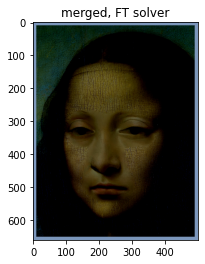

In [18]:
o_FT = solve_FT(divergence)
plt.imshow(np.clip(o_FT, 0, 1)); plt.title('merged, FT solver')


What went wrong? Well, nothing :) Integration from gradient field alone can't recover the per-channel constant factors. So, we need to adjust for that by ensuring the per-channel mean is the same as the per-channel mean of the original im_A. 



Text(0.5, 1.0, 'merged, FT solver')

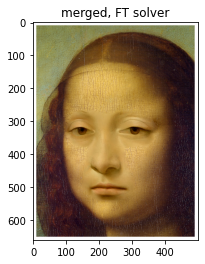

In [19]:
# mean of the original image? 
mean = im_A.mean(axis=(0,1))
o_FT += mean
plt.imshow(np.clip(o_FT, 0, 1)); plt.title('merged, FT solver')



### HDR : High Dynamic Range image computation by gradient merging 
Now we will use the algorithm for a different task. 

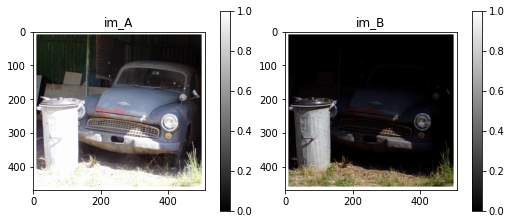

In [20]:
im_A = imread('car_high.png').astype(float)/255
im_B = imread('car_low.png').astype(float)/255
show_tuple([im_A, im_B], ['im_A', 'im_B'])

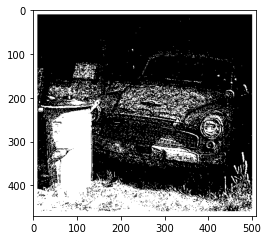

In [21]:
# compute the gradients: 
gx_A, gy_A = calc_grad(im_A)
gx_B, gy_B = calc_grad(im_B)
# compute the mask, based on which gradient is bigger:  
mask = get_mask(gx_A, gy_A, gx_B, gy_B)
plt.imshow(mask, cmap='gray')

In [22]:
# merge gradients and compute the divergence: 
gx, gy = merge_grads(gx_A, gy_A, gx_B, gy_B, mask)
divergence = calc_div(gx, gy)

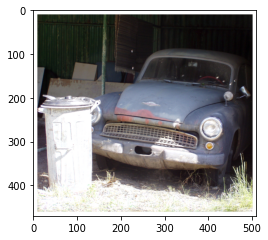

In [23]:
o = solve_GS(divergence, im_A, mask, num_iter = 150)
plt.imshow(np.clip(o, 0, 1))


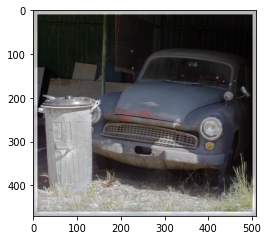

In [24]:
# by construction, the image is likely to go in intensities over 1.0 - adjust for that 
# by simply scaling the intensity down 
plt.imshow(np.clip(o*.7, 0, 1))

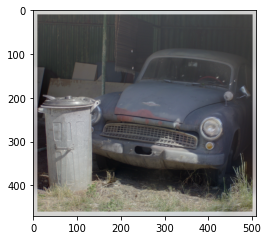

In [25]:
# try to do the same using the Fourier transform -based solution. 
o_FT = solve_FT(divergence)
# normalize as before, or just stretch the range to min-max values: 
plt.imshow(normalized(o_FT))
